# 01 · Exploratory Data Analysis

**Goal:** understand both datasets well enough to justify our features and our business framing.

Run `python -m src.data --kaggle` first 

Questions to answer (and screenshot for the slides):
1. How balanced are the quality tiers? For red vs white?
2. Which lab measurements separate *premium* from *standard*?
3. How many duplicates did we remove, and why does it matter?
4. What does the Portuguese catalog look like (regions, prices, colours)?

In [1]:
import sys
from pathlib import Path

_dir = Path.cwd()
while not (_dir / "src").is_dir() and _dir != _dir.parent:
    _dir = _dir.parent
if str(_dir) not in sys.path:
    sys.path.insert(0, str(_dir))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

wine = pd.read_csv("../data/processed/wine_quality.csv")
wine.shape, wine["wine_type"].value_counts()

((5320, 14),
 wine_type
 white    3961
 red      1359
 Name: count, dtype: int64)

## 1. Target balance

In [3]:
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_tier
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red,standard
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red,standard
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red,standard
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red,good
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,red,standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5315,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white,good
5316,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white,standard
5317,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white,good
5318,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white,premium


These variables are the physicochemical properties used to measure and analyze wine characteristics in the standard Wine Quality Dataset.

* Fixed Acidity: The amount of non-volatile acids (like tartaric acid) in wine that do not evaporate easily. 
* Volatile Acidity: The amount of acetic acid in wine, which can lead to an unpleasant vinegar taste at high levels. *
* Citric Acid: A minor acid found in wine that adds freshness and flavor.
* Residual Sugar: The amount of sugar left over after fermentation stops, indicating how sweet or dry a wine is.
* Chlorides: The amount of salt or chloride ions present in the wine. 
* Free Sulfur Dioxide: The active form of sulfur dioxide (SO₂) used to prevent microbial growth and oxidation. 
* Total Sulfur Dioxide: The sum of free and bound sulfur dioxide in the wine. 
* Density: The mass per unit volume of the wine, which is close to that of water and relates to alcohol and sugar content. 
* pH: A scale measuring how acidic or basic the wine is on a scale from 0 to 14 (most wines range between 3 and 4). 
* Sulphates: Wine additives (like potassium sulphate) that contribute to sulfur dioxide levels and act as antimicrobial and antioxidant agents.

In [4]:
pd.crosstab(wine["wine_type"], wine["quality_tier"], normalize="index").round(2)

quality_tier,good,premium,standard
wine_type,,,
red,0.39,0.14,0.47
white,0.45,0.21,0.34


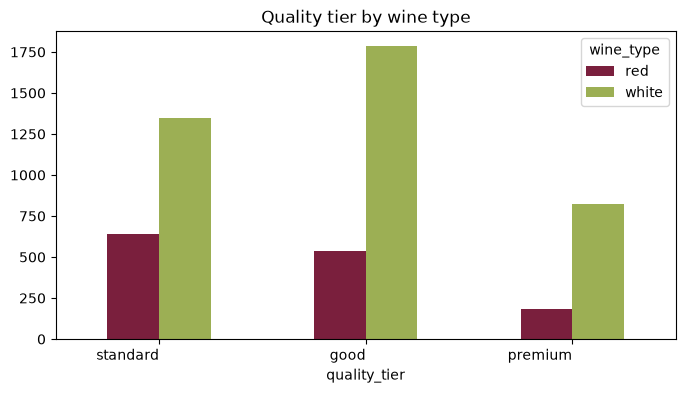

In [26]:
tier_order = ["standard", "good", "premium"]
wine.groupby("wine_type")["quality_tier"].value_counts().unstack(0).reindex(tier_order).plot.bar(
    figsize=(8,4), title="Quality tier by wine type",
    color={"red": "#7a1f3d", "white": "#9caf54"},rot=0)
plt.xticks(ha="right")
plt.show()

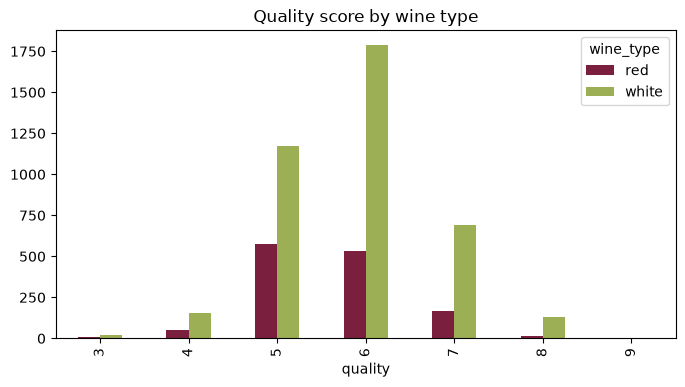

In [13]:
wine.groupby("wine_type")["quality"].value_counts().unstack(0).plot.bar(figsize=(8,4), title="Quality score by wine type",color={"red": "#7a1f3d", "white": "#9caf54"})
plt.show()

## 2. What drives quality?

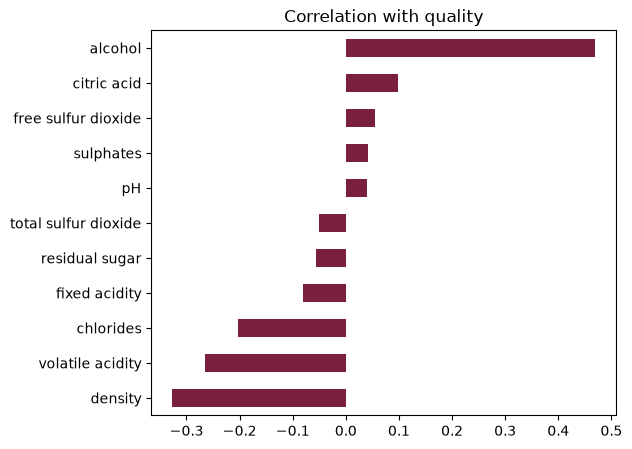

In [7]:
num = wine.select_dtypes("number").drop(columns=["quality"])
corr = num.assign(quality=wine["quality"]).corr()["quality"].drop("quality").sort_values()
corr.plot.barh(figsize=(6,5), title="Correlation with quality", color="#7a1f3d")
plt.show()

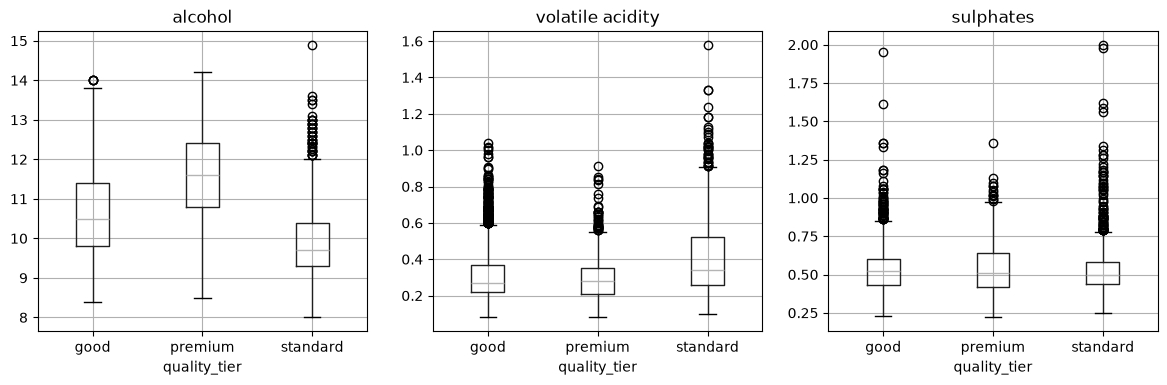

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["alcohol", "volatile acidity", "sulphates"]):
    wine.boxplot(column=col, by="quality_tier", ax=ax)
plt.suptitle("")
plt.show()

## 3. Our engineered features
Check that they add signal (compare their correlation with the raw ones).

In [9]:
from src.features import WineFeatures
from src import config
X = WineFeatures().fit_transform(wine[config.INPUT_COLUMNS])
X[["free_so2_ratio","total_acidity","alcohol_sugar_ratio","sulphates_x_alcohol"]].assign(quality=wine["quality"]).corr()["quality"]

free_so2_ratio         0.128654
total_acidity         -0.096189
alcohol_sugar_ratio    0.099428
sulphates_x_alcohol    0.212393
quality                1.000000
Name: quality, dtype: float64

## 4. Portuguese catalog (Kaggle Wine Reviews)

In [10]:
pt = pd.read_csv("../data/processed/portugal_wines.csv")
print(len(pt), "Portuguese wines")
pt["province"].value_counts()

5256 Portuguese wines


province
Douro                           1179
Alentejano                       862
Tejo                             633
Port                             565
Lisboa                           460
Vinho Verde                      382
Dão                              317
Alentejo                         169
Bairrada                         156
Península de Setúbal             139
Minho                             44
Estremadura                       41
Beira Interior                    33
Portuguese Table Wine             24
Duriense                          23
Bucelas                           21
Palmela                           21
Vinho Espumante de Qualidade      20
Setubal                           19
Beiras                            16
Ribatejano                        15
Madeira                           13
Ribatejo                          13
Beira Atlantico                   12
Trás-os-Montes                    12
Terras do Sado                    12
Obidos                       

In [11]:
pt["colour"].value_counts()

colour
red        3302
white      1481
rosé        239
unknown     234
Name: count, dtype: int64

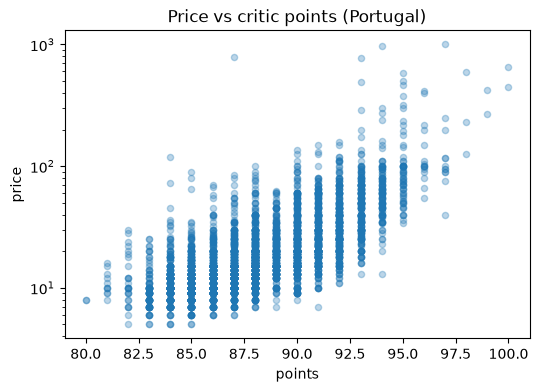

In [12]:
pt.plot.scatter(x="points", y="price", alpha=.3, figsize=(6,4), title="Price vs critic points (Portugal)")
plt.yscale("log"); plt.show()

## Takeaways 
- **Tier balance:** 5,320 wines after cleaning (3,961 white, 1,359 red). Tiers are imbalanced and skew differently by colour: white wines are more often good (45%) or premium (21%) than red (39% good, 14% premium); red wines lean standard (47% vs white's 34%). This is part of why macro-F1 (not accuracy) is the right metric as a model that just predicted "standard" a lot would look fine on accuracy but fail the wines that matter.
- **Strongest drivers:** none of the individual chemistry measurements are strong predictors on their own, sulphates_x_alcohol, our strongest driver, only correlates 0.21 with quality. 
- **Duplicates removed:** 1,177 exact duplicate rows out of 6,497 (18%) were dropped before the train/test split. It avoide the same physical wine to land in both train and test, inflating the test score with leakage rather than real generalization.
- **Catalog:** 5,256 Portuguese wines, dominated by Douro (1,179), Alentejano (862), Tejo (633), Port (565), and Vinho Verde (382), mostly red (3,302) vs white (1,481) vs rosé (239). This is where Sommelier learn about the wine.